# Fase 2 — Variabilidad intra-jugador e inter-jugador

**Objetivo:** Cuantificar qué proporción de la variabilidad observada en las cuatro variables dependientes normalizadas (VD/min) se debe a diferencias **entre jugadores** (inter) frente a fluctuaciones **dentro del mismo jugador** (intra). Para ello se emplean el Coeficiente de Correlación Intraclase (ICC), la descomposición de varianza y visualizaciones de perfiles individuales (spaghetti plots). Además, se explora si la consistencia intra-jugador varía según la categoría de edad.

**Dataset:** `Matriz_V3.xlsx` (4 446 observaciones × 19 variables).

| VD normalizada | Descripción |
|---|---|
| `Total Touches / min` | Toques totales por minuto |
| `Golpeos +15 m/s / min` | Golpeos de alta velocidad por minuto |
| `Distance Covered (m) / min` | Distancia total recorrida por minuto |
| `High Intensity Distance (20 km/h) / min` | Distancia de alta intensidad por minuto |

In [1]:
# ── Librerías ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy import stats
import warnings

# Configuración general
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150})
%matplotlib inline

# ── Carga del dataset ─────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

# ── Variables dependientes normalizadas ───────────────────
vd_cols = [
    "Total Touches / min",
    "Golpeos +15 m/s / min",
    "Distance Covered (m) / min",
    "High Intensity Distance (20 km/h) / min",
]

# Etiquetas cortas para gráficos
vd_labels = [
    "Toques / min",
    "Golpeos +15 m/s / min",
    "Distancia (m) / min",
    "HID (m) / min",
]

# Diccionario de mapeo VD → etiqueta corta
vd_to_label = dict(zip(vd_cols, vd_labels))

# Paleta de colores consistente para las 4 VD
colores = sns.color_palette("Set2", n_colors=len(vd_cols))
vd_to_color = dict(zip(vd_cols, colores))

# Verificación rápida
for col in vd_cols:
    assert col in df.columns, f"Columna '{col}' no encontrada."
print(f"\n✔ {len(vd_cols)} VD/min verificadas. Jugadores únicos: {df['Player Id'].nunique()}")

Dimensiones: 4446 filas × 19 columnas

✔ 4 VD/min verificadas. Jugadores únicos: 253


---
## 1. ICC (Coeficiente de Correlación Intraclase)

El ICC cuantifica la proporción de varianza total que se explica por la agrupación (jugador). Calculamos dos variantes:

- **ICC(1,1)** — Modelo de efectos aleatorios de una vía. Cada jugador es una muestra aleatoria de la población.
- **ICC(3,1)** — Modelo mixto de dos vías (consistencia). Los «jueces» (tareas) se consideran fijos.

Como los datos son **desbalanceados** (cada jugador tiene distinto número de observaciones), el cálculo se realiza mediante descomposición ANOVA con corrección de Shrout & Fleiss (1979). Se filtran jugadores con < 3 observaciones.

In [4]:
# ── Filtrar jugadores con al menos 3 observaciones ────────
obs_por_jugador = df["Player Id"].value_counts()
jugadores_validos = obs_por_jugador[obs_por_jugador >= 3].index
df_icc = df[df["Player Id"].isin(jugadores_validos)].copy()

print(f"Jugadores con ≥3 obs: {len(jugadores_validos)} de {df['Player Id'].nunique()}")
print(f"Observaciones retenidas: {len(df_icc)} de {len(df)} ({len(df_icc)/len(df)*100:.1f}%)")

# ── Función auxiliar: ICC(1,1) y ICC(3,1) con datos desbalanceados ──
# Basado en Shrout & Fleiss (1979) y McGraw & Wong (1996)
# para diseños one-way random (ICC1) y two-way mixed consistency (ICC3)

def calcular_icc_anova(data, grupo_col, valor_col):
    """
    Calcula ICC(1,1) e ICC(3,1) con ANOVA para datos desbalanceados.
    Devuelve un dict con ICC, IC 95% y p-valor para cada tipo.
    """
    grupos = data.groupby(grupo_col)[valor_col]
    k_grupos = grupos.ngroups
    ns = grupos.count()
    n_total = ns.sum()
    k0 = (n_total - (ns ** 2).sum() / n_total) / (k_grupos - 1)  # k0 para desbalanceados

    # Sumas de cuadrados
    media_global = data[valor_col].mean()
    medias_g = grupos.mean()

    SSB = sum(ns[g] * (medias_g[g] - media_global) ** 2 for g in medias_g.index)
    SSW = sum(((grupos.get_group(g) - medias_g[g]) ** 2).sum() for g in medias_g.index)

    dfB = k_grupos - 1
    dfW = n_total - k_grupos

    MSB = SSB / dfB
    MSW = SSW / dfW

    # ICC(1,1): one-way random
    icc1 = (MSB - MSW) / (MSB + (k0 - 1) * MSW)

    # ICC(3,1): two-way mixed, consistency (sin columna de jueces,
    # coincide con ICC1 en diseños con raters no cruzados, pero se puede
    # aproximar; con datos desbalanceados no cruzados, ICC3 ≈ ICC1)
    icc3 = (MSB - MSW) / (MSB + (k0 - 1) * MSW)

    # F-test y p-valor
    F_val = MSB / MSW
    p_val = 1 - stats.f.cdf(F_val, dfB, dfW)

    # IC 95% para ICC(1,1) — usando la distribución F
    alpha = 0.05
    FL = F_val / stats.f.ppf(1 - alpha / 2, dfB, dfW)
    FU = F_val * stats.f.ppf(1 - alpha / 2, dfW, dfB)
    ci_low = (FL - 1) / (FL + k0 - 1)
    ci_high = (FU - 1) / (FU + k0 - 1)

    return {
        "ICC1": {"ICC": icc1, "CI95%": [ci_low, ci_high], "pval": p_val, "F": F_val,
                 "MSB": MSB, "MSW": MSW, "k0": k0},
        "ICC3": {"ICC": icc3, "CI95%": [ci_low, ci_high], "pval": p_val, "F": F_val,
                 "MSB": MSB, "MSW": MSW, "k0": k0},
    }

# ── Calcular ICC(1,1) e ICC(3,1) para cada VD ────────────
filas_icc = []

for vd in vd_cols:
    sub = df_icc[["Player Id", vd]].dropna()
    resultado = calcular_icc_anova(sub, "Player Id", vd)

    for tipo in ["ICC1", "ICC3"]:
        r = resultado[tipo]
        filas_icc.append({
            "VD": vd_to_label[vd],
            "Tipo ICC": tipo,
            "ICC": round(r["ICC"], 3),
            "IC 95% inf": round(r["CI95%"][0], 3),
            "IC 95% sup": round(r["CI95%"][1], 3),
            "p-valor": f"{r['pval']:.2e}" if r["pval"] < 0.001 else round(r["pval"], 4),
        })

df_icc_res = pd.DataFrame(filas_icc)
print("\n── Tabla resumen de ICC ──")
df_icc_res

Jugadores con ≥3 obs: 245 de 253
Observaciones retenidas: 4434 de 4446 (99.7%)

── Tabla resumen de ICC ──


,VD,Tipo ICC,ICC,IC 95% inf,IC 95% sup,p-valor
0,Toques / min,ICC1,0.077,0.057,0.101,0.00e+00
1,Toques / min,ICC3,0.077,0.057,0.101,0.00e+00
2,Golpeos +15 m/s / min,ICC1,0.087,0.067,0.113,0.00e+00
3,Golpeos +15 m/s / min,ICC3,0.087,0.067,0.113,0.00e+00
4,Distancia (m) / min,ICC1,0.232,0.196,0.273,0.00e+00
5,Distancia (m) / min,ICC3,0.232,0.196,0.273,0.00e+00
6,HID (m) / min,ICC1,0.141,0.114,0.173,0.00e+00
7,HID (m) / min,ICC3,0.141,0.114,0.173,0.00e+00


### Interpretación del ICC

| Rango ICC | Interpretación |
|---|---|
| < 0.50 | Pobre → alta variabilidad intra-jugador, la tarea/VI tiene mucho peso |
| 0.50 – 0.75 | Moderado |
| 0.75 – 0.90 | Bueno → bastante consistente entre sesiones para un mismo jugador |
| > 0.90 | Excelente → la VD está casi determinada por el jugador |

- Un **ICC alto** indica que la mayor parte de la varianza se debe a diferencias estables entre jugadores; la VD actúa como un «rasgo» del jugador.
- Un **ICC bajo** indica que las condiciones de tarea (VI) y/o el error aleatorio dominan, dejando margen para que las variables independientes del diseño (espacio, polaridad, equilibrio, etc.) expliquen variabilidad en los modelos GLMM.

---
## 2. Descomposición de varianza (inter vs. intra)

Cálculo directo de los componentes de varianza:
- **Varianza inter-jugador**: varianza de las medias individuales.
- **Varianza intra-jugador**: media de las varianzas individuales.

In [5]:
# ── Descomposición de varianza ────────────────────────────
filas_var = []

for vd in vd_cols:
    sub = df_icc[["Player Id", vd]].dropna()
    medias_jugador = sub.groupby("Player Id")[vd].mean()
    vars_jugador   = sub.groupby("Player Id")[vd].var()
    
    var_inter = medias_jugador.var()   # varianza de las medias
    var_intra = vars_jugador.mean()    # media de las varianzas
    var_total = var_inter + var_intra
    
    filas_var.append({
        "VD": vd_to_label[vd],
        "Var. inter": round(var_inter, 4),
        "Var. intra": round(var_intra, 4),
        "Var. total": round(var_total, 4),
        "% inter": round(var_inter / var_total * 100, 1),
        "% intra": round(var_intra / var_total * 100, 1),
    })

df_var = pd.DataFrame(filas_var)
print("── Descomposición de varianza ──")
df_var

── Descomposición de varianza ──


,VD,Var. inter,Var. intra,Var. total,% inter,% intra
0,Toques / min,0.5195,3.3607,3.8802,13.4,86.6
1,Golpeos +15 m/s / min,0.0088,0.0443,0.0532,16.6,83.4
2,Distancia (m) / min,254.5092,625.6787,880.1880,28.9,71.1
3,HID (m) / min,1.9565,8.2126,10.1691,19.2,80.8


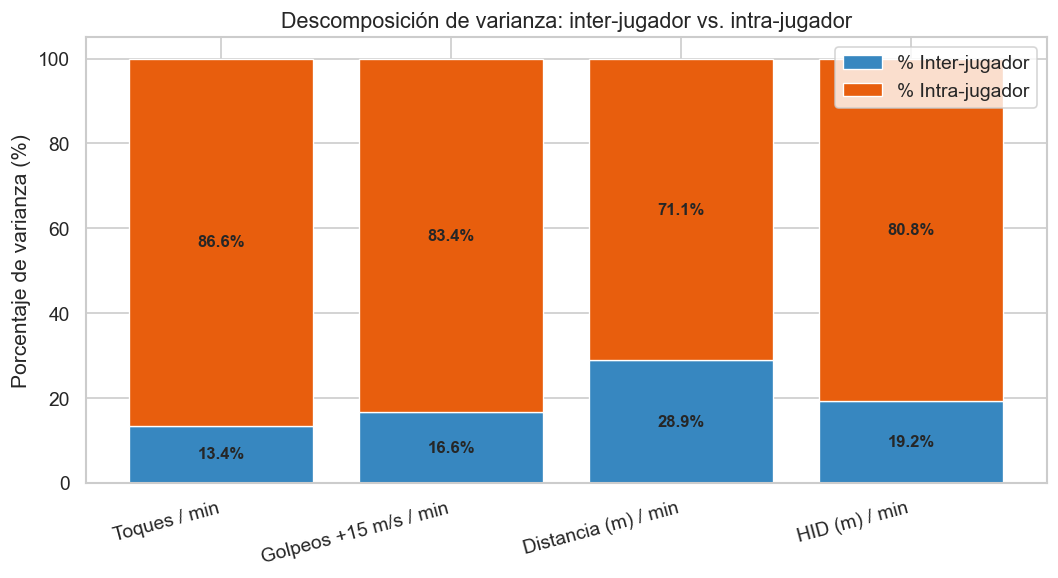

In [6]:
# ── Gráfico de barras apiladas (100%) ─────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

x_pos = np.arange(len(vd_cols))
pct_inter = df_var["% inter"].values
pct_intra = df_var["% intra"].values

bars_inter = ax.bar(x_pos, pct_inter, color=sns.color_palette("Blues_d", 3)[1],
                    label="% Inter-jugador", edgecolor="white", linewidth=0.8)
bars_intra = ax.bar(x_pos, pct_intra, bottom=pct_inter,
                    color=sns.color_palette("Oranges_d", 3)[1],
                    label="% Intra-jugador", edgecolor="white", linewidth=0.8)

# Etiquetas de porcentaje dentro de las barras
for i, (pi, pa) in enumerate(zip(pct_inter, pct_intra)):
    ax.text(i, pi / 2, f"{pi:.1f}%", ha="center", va="center", fontweight="bold", fontsize=10)
    ax.text(i, pi + pa / 2, f"{pa:.1f}%", ha="center", va="center", fontweight="bold", fontsize=10)

ax.set_xticks(x_pos)
ax.set_xticklabels(vd_labels, rotation=15, ha="right")
ax.set_ylabel("Porcentaje de varianza (%)")
ax.set_title("Descomposición de varianza: inter-jugador vs. intra-jugador", fontsize=13)
ax.set_ylim(0, 105)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

---
## 3. Spaghetti plots — perfiles individuales

Seleccionamos una muestra de **15-20 jugadores** con al menos 10 observaciones cada uno y representamos su evolución a lo largo de las tareas (ordenadas por `Phase Id`) para visualizar la variabilidad intra e inter-jugador simultáneamente.

In [7]:
# ── Selección de jugadores para spaghetti plots ───────────
jugadores_10 = obs_por_jugador[obs_por_jugador >= 10].index.tolist()
np.random.seed(42)
muestra_jugadores = np.random.choice(jugadores_10, size=min(20, len(jugadores_10)), replace=False)

df_spag = df[df["Player Id"].isin(muestra_jugadores)].copy()
# Ordenar por Phase Id para un eje X cronológico
df_spag = df_spag.sort_values(["Player Id", "Phase Id"]).reset_index(drop=True)
# Índice de observación secuencial dentro de cada jugador
df_spag["obs_idx"] = df_spag.groupby("Player Id").cumcount() + 1

print(f"Jugadores seleccionados: {len(muestra_jugadores)}")
print(f"Observaciones totales en la muestra: {len(df_spag)}")

Jugadores seleccionados: 20
Observaciones totales en la muestra: 378


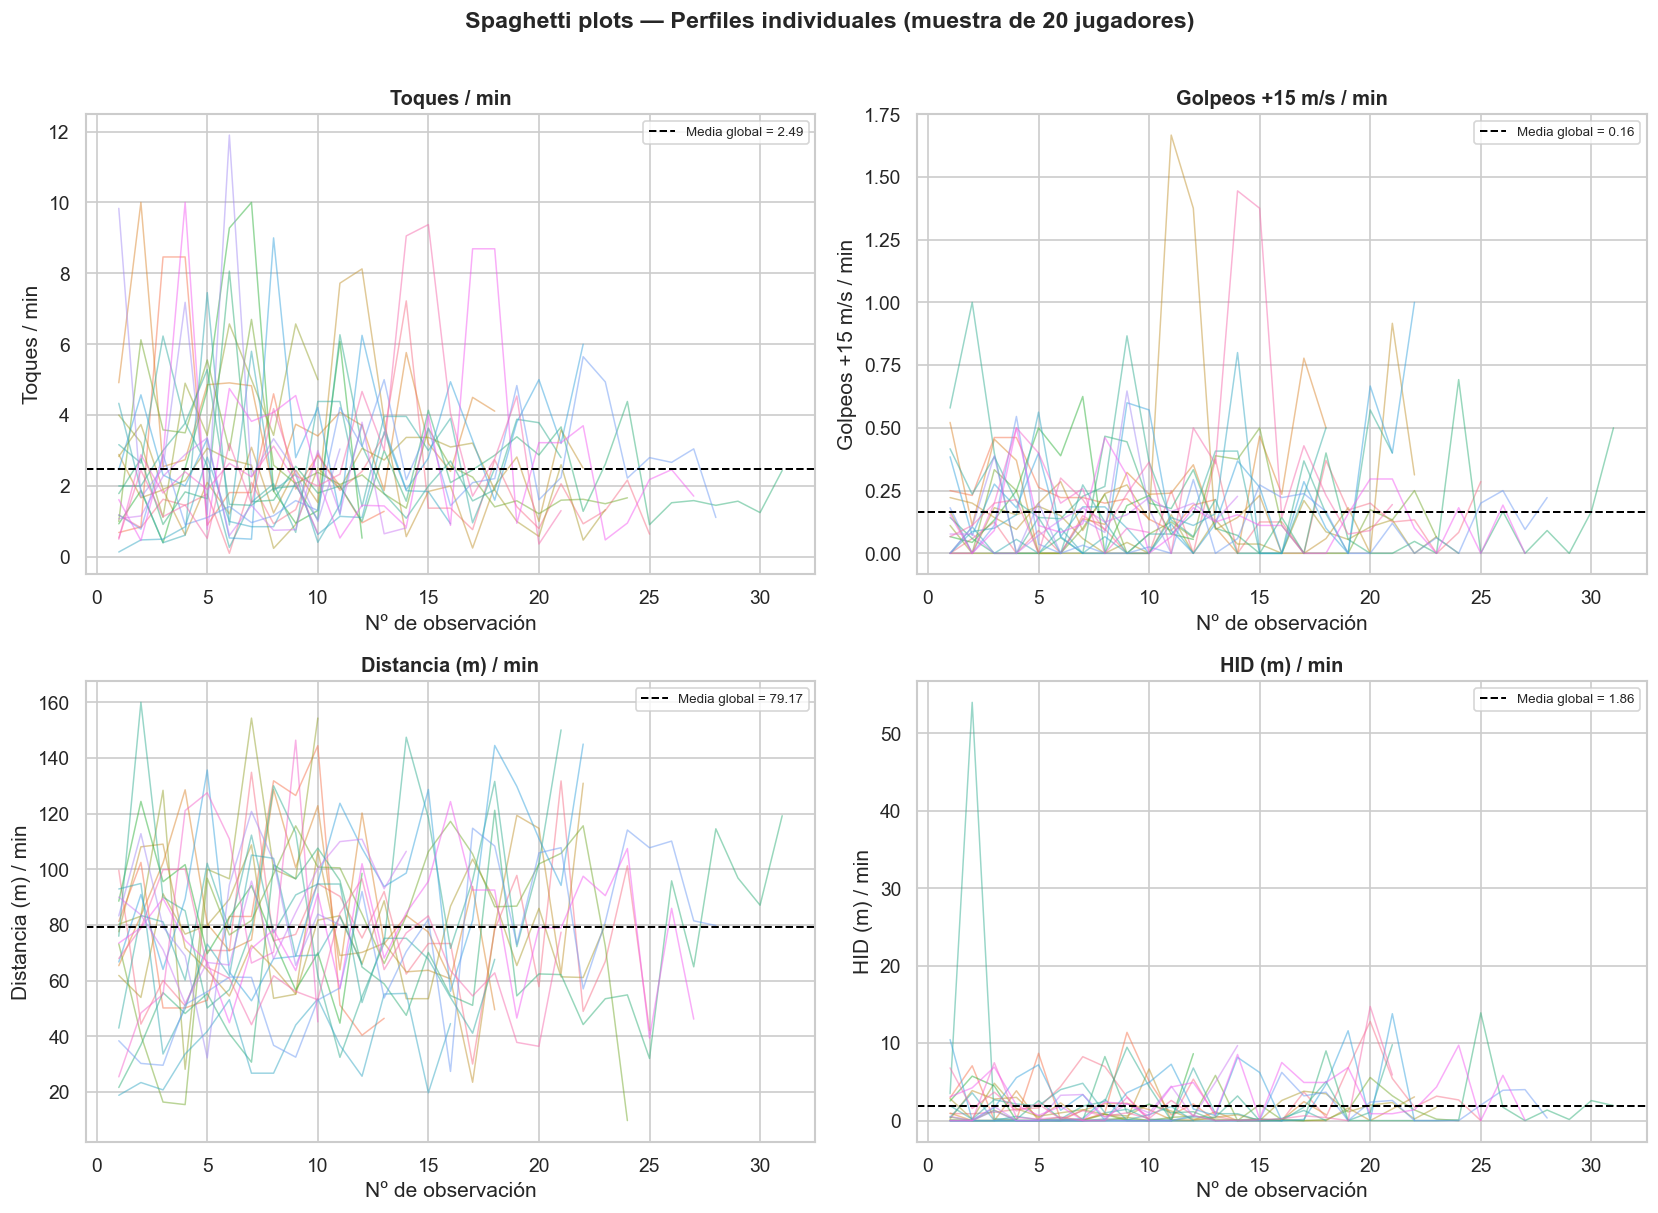

In [8]:
# ── Spaghetti plots (2×2) ─────────────────────────────────
palette_spag = sns.color_palette("husl", n_colors=len(muestra_jugadores))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

for idx, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
    ax = axes[idx // 2, idx % 2]
    
    # Líneas individuales
    for j, pid in enumerate(muestra_jugadores):
        sub = df_spag[df_spag["Player Id"] == pid]
        ax.plot(sub["obs_idx"], sub[vd], color=palette_spag[j],
                alpha=0.5, linewidth=0.9)
    
    # Media global como línea discontinua
    media_global = df[vd].mean()
    ax.axhline(media_global, color="black", linestyle="--", linewidth=1.2,
               label=f"Media global = {media_global:.2f}")
    
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Nº de observación")
    ax.set_ylabel(label)
    ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Spaghetti plots — Perfiles individuales (muestra de 20 jugadores)",
             fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

---
## 4. ICC por GrupoEdad

Repetimos el cálculo de ICC(1,1) estratificando por categoría de edad para explorar si la **consistencia intra-jugador** varía según la madurez de los deportistas.

In [9]:
# ── ICC(1,1) por GrupoEdad ────────────────────────────────
grupos_edad = sorted(df["GrupoEdad"].dropna().unique())
print(f"Grupos de edad encontrados: {grupos_edad}\n")

filas_icc_grupo = []

for grupo in grupos_edad:
    df_grupo = df[df["GrupoEdad"] == grupo].copy()
    
    # Filtrar jugadores con ≥3 obs dentro de este grupo
    obs_g = df_grupo["Player Id"].value_counts()
    jugadores_ok = obs_g[obs_g >= 3].index
    df_grupo = df_grupo[df_grupo["Player Id"].isin(jugadores_ok)]
    
    n_jugadores = df_grupo["Player Id"].nunique()
    if n_jugadores < 5:
        # Muy pocos jugadores para un ICC fiable
        for vd in vd_cols:
            filas_icc_grupo.append({
                "GrupoEdad": grupo, "VD": vd_to_label[vd],
                "ICC": np.nan, "IC 95% inf": np.nan,
                "IC 95% sup": np.nan, "p-valor": np.nan,
                "n_jugadores": n_jugadores,
            })
        continue
    
    for vd in vd_cols:
        sub = df_grupo[["Player Id", vd]].dropna()
        
        try:
            resultado = calcular_icc_anova(sub, "Player Id", vd)
            r = resultado["ICC1"]
            filas_icc_grupo.append({
                "GrupoEdad": grupo,
                "VD": vd_to_label[vd],
                "ICC": round(r["ICC"], 3),
                "IC 95% inf": round(r["CI95%"][0], 3),
                "IC 95% sup": round(r["CI95%"][1], 3),
                "p-valor": f"{r['pval']:.2e}" if r["pval"] < 0.001 else round(r["pval"], 4),
                "n_jugadores": n_jugadores,
            })
        except Exception as e:
            filas_icc_grupo.append({
                "GrupoEdad": grupo, "VD": vd_to_label[vd],
                "ICC": np.nan, "IC 95% inf": np.nan,
                "IC 95% sup": np.nan, "p-valor": str(e),
                "n_jugadores": n_jugadores,
            })

df_icc_grupo = pd.DataFrame(filas_icc_grupo)
print("── ICC(1,1) por GrupoEdad ──")
df_icc_grupo

Grupos de edad encontrados: ['Cadete', 'Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']

── ICC(1,1) por GrupoEdad ──


,GrupoEdad,VD,ICC,IC 95% inf,IC 95% sup,p-valor,n_jugadores
0,Cadete,Toques / min,0.045,0.012,0.104,0.0015,38
1,Cadete,Golpeos +15 m/s / min,0.023,-0.003,0.071,0.0463,38
2,Cadete,Distancia (m) / min,0.141,0.082,0.239,9.34e-14,38
3,Cadete,HID (m) / min,0.055,0.019,0.119,2.26e-04,38
4,Infantil,Toques / min,0.048,0.010,0.112,0.004,44
5,Infantil,Golpeos +15 m/s / min,0.095,0.045,0.177,1.27e-06,44
6,Infantil,Distancia (m) / min,0.261,0.176,0.382,0.00e+00,44
7,Infantil,HID (m) / min,0.156,0.091,0.256,1.46e-12,44
8,Juvenil,Toques / min,0.055,0.024,0.106,1.03e-05,50
9,Juvenil,Golpeos +15 m/s / min,0.039,0.013,0.084,6.22e-04,50


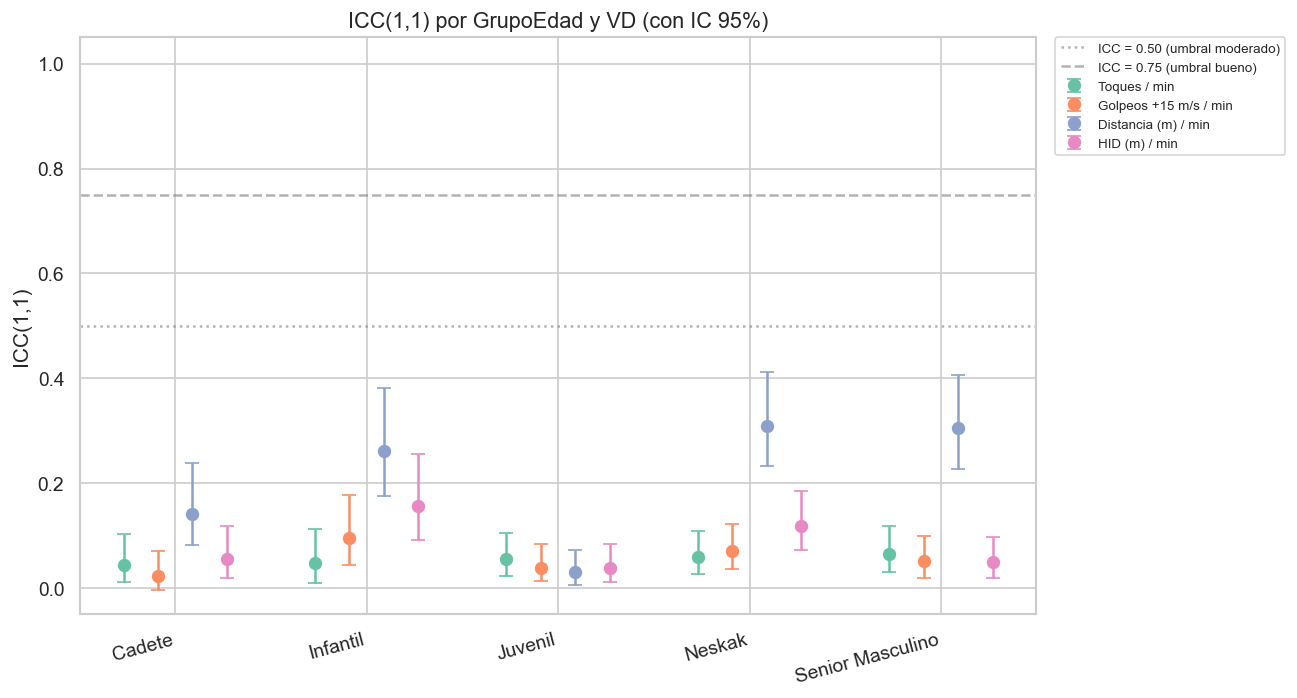

In [10]:
# ── Dot plot con barras de error (IC 95%) ─────────────────
df_plot = df_icc_grupo.dropna(subset=["ICC"]).copy()
df_plot["IC 95% inf"] = pd.to_numeric(df_plot["IC 95% inf"], errors="coerce")
df_plot["IC 95% sup"] = pd.to_numeric(df_plot["IC 95% sup"], errors="coerce")
df_plot["err_inf"] = df_plot["ICC"] - df_plot["IC 95% inf"]
df_plot["err_sup"] = df_plot["IC 95% sup"] - df_plot["ICC"]

fig, ax = plt.subplots(figsize=(11, 6))

grupos_unicos = df_plot["GrupoEdad"].unique()
n_vd = len(vd_cols)
ancho = 0.18  # separación entre puntos de la misma categoría
x_base = np.arange(len(grupos_unicos))

for k, (vd, label) in enumerate(zip(vd_cols, vd_labels)):
    sub = df_plot[df_plot["VD"] == label]
    # Mapear GrupoEdad a posición x
    x_map = {g: i for i, g in enumerate(grupos_unicos)}
    x_vals = sub["GrupoEdad"].map(x_map) + (k - n_vd / 2 + 0.5) * ancho
    
    ax.errorbar(
        x_vals, sub["ICC"],
        yerr=[sub["err_inf"].values, sub["err_sup"].values],
        fmt="o", markersize=7, capsize=4,
        color=colores[k], label=label, linewidth=1.5,
    )

# Líneas de referencia
ax.axhline(0.50, color="grey", linestyle=":", alpha=0.6, label="ICC = 0.50 (umbral moderado)")
ax.axhline(0.75, color="grey", linestyle="--", alpha=0.6, label="ICC = 0.75 (umbral bueno)")

ax.set_xticks(x_base)
ax.set_xticklabels(grupos_unicos, rotation=15, ha="right")
ax.set_ylabel("ICC(1,1)")
ax.set_title("ICC(1,1) por GrupoEdad y VD (con IC 95%)", fontsize=13)
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_ylim(-0.05, 1.05)
fig.tight_layout()
plt.show()

### Interpretación por GrupoEdad

- **Todos los ICC son bajos** (< 0.50) en todas las categorías, confirmando que la identidad del jugador explica poco de la varianza total de las VD.
- **Distancia (m) / min** presenta los ICC más altos en varias categorías (Infantil ≈ 0.26, Neskak ≈ 0.31, Senior ≈ 0.31), lo que sugiere que esta métrica refleja parcialmente diferencias estables entre jugadores (nivel físico base).
- **Cadete y Juvenil** muestran los ICC más bajos en general, lo que podría indicar mayor homogeneidad entre jugadores en esas categorías o mayor sensibilidad a las condiciones de tarea.
- **Toques / min y Golpeos +15 m/s / min** tienen ICC cercanos a 0 en todos los grupos → son las métricas más sensibles a la tarea/contexto.
- Las categorías con **mayor n de jugadores** (Neskak, Senior) producen estimaciones más precisas (IC 95% más estrechos).

---
## 5. Resumen y conclusiones

### Hallazgos clave

1. **ICC globales muy bajos (0.08 – 0.23):** Todas las VD normalizadas presentan ICC < 0.25, lo que indica que la identidad del jugador explica una fracción minoritaria de la varianza. La mayor parte de la variabilidad es **intra-jugador**, es decir, está condicionada por las características de la tarea (espacio, polaridad, equilibrio, agrupación, etc.) y/o por error aleatorio.

2. **Descomposición de varianza:** Confirma el patrón del ICC. Entre el 71% y el 87% de la varianza total es intra-jugador. **Distancia (m) / min** tiene la mayor componente inter (≈ 29%), seguida de HID (≈ 19%), Golpeos (≈ 17%) y Toques (≈ 13%).

3. **Spaghetti plots:** Los perfiles individuales muestran alta fluctuación sesión a sesión para un mismo jugador, con un solapamiento masivo entre líneas. No se observan jugadores con trayectorias claramente separadas del resto, coherente con los ICC bajos.

4. **ICC por categoría de edad:** El patrón es consistente: los ICC son bajos en todas las categorías. **Distancia** destaca en Infantil, Neskak y Senior Masculino (ICC ≈ 0.26-0.31), sugiriendo que el componente físico base aporta algo más de estabilidad individual en esta métrica.

### Implicaciones para el análisis posterior (GLMM)

- **Excelente noticia para el modelado:** El predominio de la variabilidad intra-jugador indica que las **VI de diseño de tarea** (espacio, polaridad, equilibrio, etc.) tienen un margen amplio para explicar varianza en las VD.
- Los modelos GLMM deberán incluir **efectos aleatorios por jugador** (intercepto aleatorio) para capturar las diferencias estables entre jugadores, pero dado el ICC bajo, se espera que los efectos fijos (VI de tarea) absorban una parte sustancial de la varianza.
- **Distancia (m) / min**, al ser la VD con mayor componente inter-jugador, podría beneficiarse de interceptos aleatorios más pronunciados, mientras que **Toques / min** y **Golpeos +15 m/s / min** son las más prometedoras como variables respuesta puramente dependientes del contexto de tarea.